# 🌿 PlantBot — YOLO-Lite Object Detection From Scratch

## Mục tiêu
Xây dựng mô hình **Single-Stage Object Detection** siêu nhẹ để phát hiện vết bệnh trên lá cây Cải thìa (Bok Choy).

## Kiến trúc
- **Backbone:** Toàn bộ `DepthwiseSeparableConv2d` (giảm params ~9× so với Conv thường)
- **Detection Head:** Grid-based $S \times S$ (giống YOLO v1)
- **Output:** Mỗi grid cell dự đoán `(tx, ty, tw, th, objectness, class_probs...)`
- **Target Hardware:** Raspberry Pi 5 (CPU-only, ~300KB model)

## Pipeline
```
Cell 1: Custom Dataset & DataLoader (Grid target + Background handling)
Cell 2: Kiến trúc YOLO-Lite (DepthwiseSeparableConv)
Cell 3: Multi-task Loss (3 thành phần: Objectness + BBox + Classification)
Cell 4: Training Loop & Validation
Cell 5: Inference & NMS → Vẽ Bounding Box
```

In [28]:
!pip install -q roboflow opencv-python-headless

---
## Cấu hình & Tải Dataset

In [29]:
import os
import math
import random
import yaml
import numpy as np
import cv2
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ═══════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════
class CFG:
    # --- Roboflow ---
    ROBOFLOW_API_KEY = "m84yy3vIbXagdMl6aOZd"
    WORKSPACE        = "hi-anh"
    PROJECT          = "bok-choy-lettuce-spinach-diseased-jg4ui"
    VERSION          = 3

    # --- Model Architecture ---
    IMG_SIZE     = 224     # Input size (nhỏ → nhanh trên RPi5)
    GRID_SIZE    = 7       # S×S grid: 224 / 2^5 = 7
    NUM_CLASSES  = None    # Sẽ cập nhật từ data.yaml

    # --- Training ---
    EPOCHS       = 8
    BATCH_SIZE   = 16
    LR           = 1e-3
    WEIGHT_DECAY = 1e-3

    # --- Loss Weights (λ) ---
    # λ_obj >> λ_noobj: Phạt NẶNG bỏ lọt vết bệnh nhỏ
    LAMBDA_COORD  = 5.0    # Bbox regression
    LAMBDA_OBJ    = 5.0    # Có object mà đoán không
    LAMBDA_NOOBJ  = 0.5    # Không object mà đoán có
    LAMBDA_CLS    = 3.0    # Phân loại sai lớp

    # --- Inference ---
    CONF_THRESHOLD = 0.25
    NMS_THRESHOLD  = 0.45

    # --- Misc ---
    SEED        = 42
    NUM_WORKERS = 2
    DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_DIR    = None     # Set sau khi download


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.SEED)
print(f"✅ Device: {CFG.DEVICE}")

✅ Device: cuda


In [30]:
# ── Tải dataset từ Roboflow ──────────────────────────────────
from roboflow import Roboflow

rf = Roboflow(api_key=CFG.ROBOFLOW_API_KEY)
project = rf.workspace(CFG.WORKSPACE).project(CFG.PROJECT)
dataset = project.version(CFG.VERSION).download("yolov8")

CFG.DATA_DIR = dataset.location

# Đọc data.yaml để lấy class names
yaml_path = os.path.join(CFG.DATA_DIR, "data.yaml")
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

CFG.NUM_CLASSES = data_cfg.get("nc", 1)
CLASS_NAMES = data_cfg.get("names", [f"class_{i}" for i in range(CFG.NUM_CLASSES)])

print(f"\n📊 Dataset Info:")
print(f"   Classes ({CFG.NUM_CLASSES}): {CLASS_NAMES}")
print(f"   Grid: {CFG.GRID_SIZE}×{CFG.GRID_SIZE}")
print(f"   Output/cell: 5 + {CFG.NUM_CLASSES} = {5 + CFG.NUM_CLASSES}")

loading Roboflow workspace...
loading Roboflow project...

📊 Dataset Info:
   Classes (1): ['Diseased']
   Grid: 7×7
   Output/cell: 5 + 1 = 6


---
## Cell 1 — Custom Dataset & DataLoader

### Toán học Grid Encoding

Chia ảnh thành lưới $S \times S$. Mỗi ô lưới có kích thước $\frac{\text{IMG\_SIZE}}{S}$ pixel.

Với mỗi bounding box ở định dạng YOLO $(c_x, c_y, w, h)$ đã normalize $[0,1]$:

1. **Tìm ô lưới** chứa tâm object:  
   $g_i = \lfloor c_x \times S \rfloor$ (cột), $g_j = \lfloor c_y \times S \rfloor$ (hàng)

2. **Offset tâm** trong ô lưới $[0, 1]$:  
   $t_x = c_x \times S - g_i$, $t_y = c_y \times S - g_j$

3. **Kích thước bbox** giữ nguyên normalize:  
   $t_w = w$, $t_h = h$

4. **Target tensor** tại cell $(g_j, g_i)$:  
   $[t_x, t_y, t_w, t_h, \underbrace{1.0}_{\text{objectness}}, \underbrace{\text{one-hot}}_{\text{class}}]$

### Background Training
Ảnh không có file `.txt` hoặc file rỗng → Target tensor = $\mathbf{0}$  
→ Objectness = 0 tại **MỌI** ô lưới → Mạng học ép confidence về 0 cho vùng đất/rác.

In [31]:
class PlantDiseaseGridDataset(Dataset):
    """
    Custom Dataset chuyển YOLO labels → Grid target tensors.

    Background Handling:
        Ảnh không có file .txt hoặc file rỗng → target = zeros(S, S, 5+C)
        → Objectness = 0 tại mọi cell → Mạng ép confidence về 0.
    """

    # ImageNet normalization (dùng vì backbone train from scratch
    # vẫn cần normalize để gradient ổn định)
    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, root, split="train", img_size=224,
                 grid_size=7, num_classes=1, augment=False):
        self.img_size = img_size
        self.S = grid_size
        self.C = num_classes
        self.augment = augment

        self.img_dir = Path(root) / split / "images"
        self.lbl_dir = Path(root) / split / "labels"

        # Quét tất cả ảnh (bao gồm cả background không có label)
        self.images = []
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"):
            self.images.extend(sorted(self.img_dir.glob(ext)))

        # Thống kê
        n_with_label = sum(
            1 for img in self.images
            if (self.lbl_dir / (img.stem + ".txt")).exists()
            and (self.lbl_dir / (img.stem + ".txt")).stat().st_size > 0
        )
        n_bg = len(self.images) - n_with_label
        print(f"  [{split:5s}] {len(self.images):5d} ảnh | "
              f"{n_with_label:4d} có label | {n_bg:4d} background")

    def __len__(self):
        return len(self.images)

    # ── Load YOLO labels ──────────────────────────────────────
    def _load_labels(self, img_path):
        """
        Đọc file .txt YOLO format. Trả về list rỗng cho background.
        Format mỗi dòng: class_id cx cy w h (normalize [0,1])
        """
        lbl_path = self.lbl_dir / (img_path.stem + ".txt")
        labels = []
        if lbl_path.exists() and lbl_path.stat().st_size > 0:
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        cx, cy, w, h = map(float, parts[1:5])
                        # Clamp để tránh tràn biên
                        cx = max(0.001, min(cx, 0.999))
                        cy = max(0.001, min(cy, 0.999))
                        w  = max(0.001, min(w,  0.999))
                        h  = max(0.001, min(h,  0.999))
                        labels.append((cls_id, cx, cy, w, h))
        return labels

    # ── Augmentation (đơn giản, tương thích bbox) ─────────────
    def _augment_image_and_labels(self, img, labels):
        """
        Data augmentation nhẹ, phù hợp IoT training.
        Khi flip ảnh ngang, cx_new = 1 - cx (đối xứng trục Y).
        """
        # Random horizontal flip
        if random.random() > 0.5:
            img = cv2.flip(img, 1)
            labels = [
                (cls, 1.0 - cx, cy, w, h)
                for cls, cx, cy, w, h in labels
            ]

        # Random brightness & contrast
        if random.random() > 0.5:
            alpha = random.uniform(0.7, 1.3)   # contrast
            beta  = random.uniform(-25, 25)     # brightness
            img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

        # Random HSV jitter (mô phỏng thay đổi ánh sáng ngoài trời)
        if random.random() > 0.4:
            hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
            hsv[:, :, 0] = np.clip(hsv[:, :, 0] + random.uniform(-10, 10), 0, 179)
            hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.7, 1.3), 0, 255)
            hsv[:, :, 2] = np.clip(hsv[:, :, 2] * random.uniform(0.7, 1.3), 0, 255)
            img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        return img, labels

    # ── Build Grid Target Tensor ──────────────────────────────
    def _build_grid_target(self, labels):
        """
        Chuyển list bbox YOLO → Grid target tensor (S, S, 5+C).

        Mỗi cell: [tx, ty, tw, th, objectness, class_one_hot...]

        ⚠ Background image (labels = []) → tensor toàn 0
           → objectness = 0 ở MỌI cell
           → Mạng học: "khu vực này là đất/rác, không có vật thể"
        """
        target = torch.zeros(self.S, self.S, 5 + self.C)

        for cls_id, cx, cy, w, h in labels:
            # ── Bước 1: Xác định ô lưới chứa tâm ──
            #   gi = floor(cx * S) → chỉ số cột
            #   gj = floor(cy * S) → chỉ số hàng
            gi = int(cx * self.S)
            gj = int(cy * self.S)
            gi = min(gi, self.S - 1)
            gj = min(gj, self.S - 1)

            # Chỉ gán nếu cell chưa bị chiếm (first-come-first-served)
            if target[gj, gi, 4] == 0:
                # ── Bước 2: Offset tâm trong cell [0, 1] ──
                #   tx = cx*S - gi (phần thập phân)
                #   ty = cy*S - gj
                tx = cx * self.S - gi
                ty = cy * self.S - gj

                target[gj, gi, 0] = tx
                target[gj, gi, 1] = ty
                target[gj, gi, 2] = w    # Width normalize [0,1]
                target[gj, gi, 3] = h    # Height normalize [0,1]
                target[gj, gi, 4] = 1.0  # Objectness = 1 (có vật thể)

                # ── Bước 3: One-hot classification ──
                cls_idx = min(cls_id, self.C - 1)
                target[gj, gi, 5 + cls_idx] = 1.0

        return target

    # ── __getitem__ ───────────────────────────────────────────
    def __getitem__(self, idx):
        img_path = self.images[idx]

        # Load ảnh
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Load labels (rỗng cho background images)
        labels = self._load_labels(img_path)

        # Augmentation
        if self.augment:
            img, labels = self._augment_image_and_labels(img, labels)

        # Ảnh → Tensor normalize
        img_f = img.astype(np.float32) / 255.0
        img_f = (img_f - self.MEAN) / self.STD
        img_tensor = torch.from_numpy(img_f).permute(2, 0, 1)  # (3, H, W)

        # Labels → Grid target tensor
        target = self._build_grid_target(labels)

        return img_tensor, target

In [32]:
# ═══════════════════════════════════════════════════════════════
# DATALOADER
# ═══════════════════════════════════════════════════════════════
# Grid target có shape cố định (S, S, 5+C) → dùng được default
# collate (torch.stack). Không cần custom collate_fn!

print("📂 Chuẩn bị DataLoader...")

train_ds = PlantDiseaseGridDataset(
    CFG.DATA_DIR, split="train", img_size=CFG.IMG_SIZE,
    grid_size=CFG.GRID_SIZE, num_classes=CFG.NUM_CLASSES,
    augment=True
)
val_ds = PlantDiseaseGridDataset(
    CFG.DATA_DIR, split="valid", img_size=CFG.IMG_SIZE,
    grid_size=CFG.GRID_SIZE, num_classes=CFG.NUM_CLASSES,
    augment=False
)
test_ds = PlantDiseaseGridDataset(
    CFG.DATA_DIR, split="test", img_size=CFG.IMG_SIZE,
    grid_size=CFG.GRID_SIZE, num_classes=CFG.NUM_CLASSES,
    augment=False
)

train_loader = DataLoader(
    train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True
)

print(f"\n  Train batches: {len(train_loader)}")
print(f"  Val batches  : {len(val_loader)}")
print(f"  Test batches : {len(test_loader)}")

# Kiểm tra shape
sample_img, sample_target = train_ds[0]
print(f"\n  Sample image shape : {sample_img.shape}")
print(f"  Sample target shape: {sample_target.shape}")
print(f"  Cells có object    : {(sample_target[:,:,4] == 1).sum().item()}")

📂 Chuẩn bị DataLoader...
  [train]  7509 ảnh | 7509 có label |    0 background
  [valid]   715 ảnh |  714 có label |    1 background
  [test ]   357 ảnh |  357 có label |    0 background

  Train batches: 469
  Val batches  : 45
  Test batches : 23

  Sample image shape : torch.Size([3, 224, 224])
  Sample target shape: torch.Size([7, 7, 6])
  Cells có object    : 1


---
## Cell 2 — Kiến trúc YOLO-Lite (DepthwiseSeparableConv)

### DepthwiseSeparableConv2d
Thay thế `Conv2d` thông thường bằng 2 bước:

| | Conv thường | DSConv |
|---|---|---|
| Params | $C_{in} \times C_{out} \times K^2$ | $C_{in} \times K^2 + C_{in} \times C_{out}$ |
| Ví dụ (64→128, K=3) | 73,728 | 8,768 |
| **Giảm** | — | **~8.4×** |

### Kiến trúc Backbone
```
Input: (B, 3, 224, 224)
  │
  ├─ Conv2d(3→32, s=2)      → 32 × 112 × 112
  ├─ DSConv(32→64, s=2)     → 64 × 56 × 56
  ├─ DSConv(64→64, s=1)     → 64 × 56 × 56  [refinement]
  ├─ DSConv(64→128, s=2)    → 128 × 28 × 28
  ├─ DSConv(128→128, s=1)   → 128 × 28 × 28 [refinement]
  ├─ DSConv(128→256, s=2)   → 256 × 14 × 14
  ├─ DSConv(256→256, s=1)   → 256 × 14 × 14 [refinement]
  ├─ DSConv(256→512, s=2)   → 512 × 7 × 7
  ├─ DSConv(512→512, s=1)   → 512 × 7 × 7   [refinement]
  │
  └─ Head: Conv1×1(512 → 5+C) → (5+C) × 7 × 7
     └─ Permute → (B, 7, 7, 5+C)
```

In [33]:
class DepthwiseSeparableConv2d(nn.Module):
    """
    Depthwise Separable Convolution (MobileNet-style).

    Tách Conv2d(in→out, K×K) thành:
      1. Depthwise Conv: Conv2d(in, in, K, groups=in)
         → Mỗi input channel convolved riêng biệt
         → Params = in_ch × K × K

      2. Pointwise Conv: Conv2d(in, out, 1×1)
         → Trộn thông tin giữa các channel
         → Params = in_ch × out_ch

    Tổng params:   in_ch × K² + in_ch × out_ch
    Conv thường:   in_ch × out_ch × K²
    → Giảm ~K² lần (K=3 → ~9×)

    ReLU6 thay vì ReLU:
      Clip output tại 6 → ổn định trên phần cứng integer (int8)
      của các thiết bị IoT.
    """

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # Depthwise: convolve từng channel riêng biệt
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=3,
            stride=stride, padding=1,
            groups=in_channels, bias=False   # groups=in → depthwise
        )
        self.bn1 = nn.BatchNorm2d(in_channels)

        # Pointwise: 1×1 conv trộn channels
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU6(inplace=True)

    def forward(self, x):
        x = self.act(self.bn1(self.depthwise(x)))
        x = self.act(self.bn2(self.pointwise(x)))
        return x


class YOLOLiteDetector(nn.Module):
    """
    YOLO-Lite: Single-Stage Grid Detector siêu nhẹ.

    Output: (B, S, S, 5+C)
      - [0:2]   tx, ty  (offset tâm trong cell, raw logits)
      - [2:4]   tw, th  (kích thước bbox normalize, raw logits)
      - [4]     objectness (raw logit)
      - [5:5+C] class probabilities (raw logits)

    Kích thước ước tính: ~350K params → ~1.4 MB (.pt)
    So sánh: YOLOv8n = ~3.2M params → ~6 MB
    → Giảm ~9× params, ~4× kích thước file!
    """

    def __init__(self, num_classes=1, grid_size=7):
        super().__init__()
        self.S = grid_size
        self.C = num_classes
        self.output_dim = 5 + num_classes

        # ── Stem: Conv thường cho lớp đầu (input chỉ 3 channel) ──
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
        )

        # ── Backbone: Toàn bộ DepthwiseSeparableConv ──
        # Stride=2 giảm spatial, Stride=1 refine features
        self.backbone = nn.Sequential(
            # Block 1: 112→56
            DepthwiseSeparableConv2d(32,  64,  stride=2),
            DepthwiseSeparableConv2d(64,  64,  stride=1),
            # Block 2: 56→28
            DepthwiseSeparableConv2d(64,  128, stride=2),
            DepthwiseSeparableConv2d(128, 128, stride=1),
            # Block 3: 28→14
            DepthwiseSeparableConv2d(128, 256, stride=2),
            DepthwiseSeparableConv2d(256, 256, stride=1),
            # Block 4: 14→7
            DepthwiseSeparableConv2d(256, 512, stride=2),
            DepthwiseSeparableConv2d(512, 512, stride=1),
        )

        # ── Detection Head ──
        # 1×1 Conv: Ánh xạ 512 features → (5+C) predictions/cell
        self.head = nn.Sequential(
            nn.Dropout2d(p=0.5),
            nn.Conv2d(512, self.output_dim, kernel_size=1),
        )

        # Khởi tạo weights
        self._init_weights()

    def _init_weights(self):
        """Kaiming init cho Conv, constant init cho BN."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_out', nonlinearity='relu'
                )
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 3, 224, 224)
        x = self.stem(x)       # (B, 32, 112, 112)
        x = self.backbone(x)   # (B, 512, 7, 7)
        x = self.head(x)       # (B, 5+C, 7, 7)

        # Permute: (B, Channels, S, S) → (B, S, S, Channels)
        x = x.permute(0, 2, 3, 1).contiguous()
        return x  # (B, S, S, 5+C)


# ── Khởi tạo & In thông tin ──────────────────────────────────
model = YOLOLiteDetector(
    num_classes=CFG.NUM_CLASSES,
    grid_size=CFG.GRID_SIZE
).to(CFG.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = total_params * 4 / (1024 ** 2)  # float32 = 4 bytes

print(f"\n🏗️  YOLO-Lite Detector")
print(f"   Grid        : {CFG.GRID_SIZE}×{CFG.GRID_SIZE}")
print(f"   Output/cell : {5 + CFG.NUM_CLASSES} (5 bbox + {CFG.NUM_CLASSES} class)")
print(f"   Total params: {total_params:,}")
print(f"   Trainable   : {trainable_params:,}")
print(f"   Model size  : ~{model_size_mb:.2f} MB (float32)")
print(f"   Device      : {CFG.DEVICE}")

# Kiểm tra forward pass
with torch.no_grad():
    dummy = torch.randn(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(CFG.DEVICE)
    out = model(dummy)
    print(f"\n   Forward check: input {dummy.shape} → output {out.shape} ✅")


🏗️  YOLO-Lite Detector
   Grid        : 7×7
   Output/cell : 6 (5 bbox + 1 class)
   Total params: 545,926
   Trainable   : 545,926
   Model size  : ~2.08 MB (float32)
   Device      : cuda

   Forward check: input torch.Size([1, 3, 224, 224]) → output torch.Size([1, 7, 7, 6]) ✅


---
## Cell 3 — Multi-task Loss (3 Thành Phần)

### Công thức tổng hợp

$$\mathcal{L}_{total} = \lambda_{coord} \cdot \mathcal{L}_{bbox} + \lambda_{obj} \cdot \mathcal{L}_{obj} + \lambda_{noobj} \cdot \mathcal{L}_{noobj} + \lambda_{cls} \cdot \mathcal{L}_{cls}$$

| Thành phần | Hàm Loss | Ý nghĩa | λ |
|---|---|---|---|
| $\mathcal{L}_{bbox}$ | MSE | Phạt lệch tọa độ $(t_x, t_y, t_w, t_h)$ | 5.0 |
| $\mathcal{L}_{obj}$ | BCE | Phạt bỏ lọt vật thể (objectness → 1) | 5.0 |
| $\mathcal{L}_{noobj}$ | BCE | Phạt false positive (objectness → 0) | 0.5 |
| $\mathcal{L}_{cls}$ | BCE | Phạt sai lớp bệnh | 3.0 |

### Tại sao $\lambda_{obj} = 10 \times \lambda_{noobj}$?
Trong lưới $7 \times 7 = 49$ cells, chỉ ~2-5 cells chứa vết bệnh (rất nhỏ so với lá).  
Nếu trọng số bằng nhau, gradient bị **dominated** bởi 44+ background cells.  
→ Cần phạt **nặng gấp 10x** khi bỏ lọt object để mạng không lười biếng đoán toàn 0.

In [34]:
class YOLOLiteMultiTaskLoss(nn.Module):
    """
    Multi-task Loss cho YOLO-Lite Grid Detection.

    3 thành phần phạt tách biệt:
      1. L_bbox   (MSE)  — Regression tọa độ
      2. L_obj    (BCE)  — Objectness (có/không có vật thể)
      3. L_cls    (BCE)  — Classification (loại bệnh)

    Trọng số λ được thiết kế để phạt NẶNG khi bỏ lọt vết bệnh
    (vì vết bệnh rất nhỏ, chiếm ít cells trong grid).
    """

    def __init__(self, lambda_coord=5.0, lambda_obj=5.0,
                 lambda_noobj=0.5, lambda_cls=3.0):
        super().__init__()
        self.lambda_coord  = lambda_coord
        self.lambda_obj    = lambda_obj
        self.lambda_noobj  = lambda_noobj
        self.lambda_cls    = lambda_cls

        # BCEWithLogitsLoss: Tự apply sigmoid trước BCE
        # → Ổn định số học hơn sigmoid() + BCELoss()
        self.bce = nn.BCEWithLogitsLoss(reduction='mean')
        self.mse = nn.MSELoss(reduction='mean')

    def forward(self, predictions, targets):
        """
        Args:
            predictions: (B, S, S, 5+C) raw logits từ model
            targets:     (B, S, S, 5+C) grid targets
        Returns:
            total_loss (scalar), loss_dict (dict[str, float])
        """
        device = predictions.device

        # ── Tách predictions ──────────────────────────────────
        # Sigmoid cho bbox để ép về [0,1] trước MSE
        pred_xy  = torch.sigmoid(predictions[..., 0:2])
        pred_wh  = torch.sigmoid(predictions[..., 2:4])
        pred_obj = predictions[..., 4]     # Raw logit → BCEWithLogits
        pred_cls = predictions[..., 5:]    # Raw logits → BCEWithLogits

        # ── Tách targets ──────────────────────────────────────
        target_xy  = targets[..., 0:2]
        target_wh  = targets[..., 2:4]
        target_obj = targets[..., 4]
        target_cls = targets[..., 5:]

        # ── Masks ─────────────────────────────────────────────
        obj_mask   = (target_obj == 1)   # Cells CÓ object
        noobj_mask = (target_obj == 0)   # Cells KHÔNG có object
        n_obj   = obj_mask.sum().item()
        n_noobj = noobj_mask.sum().item()

        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # THÀNH PHẦN 1: L_bbox (MSE — Bbox Regression)
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # Chỉ tính tại cells CÓ object.
        # MSE(σ(pred_xy), target_xy) + MSE(σ(pred_wh), target_wh)
        if n_obj > 0:
            loss_xy = self.mse(pred_xy[obj_mask], target_xy[obj_mask])
            loss_wh = self.mse(pred_wh[obj_mask], target_wh[obj_mask])
            loss_bbox = loss_xy + loss_wh
        else:
            loss_bbox = torch.tensor(0.0, device=device)

        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # THÀNH PHẦN 2: L_obj (BCE — Objectness)
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # a) Cells CÓ object: BCE(pred_obj, 1)
        #    → Phạt nặng (λ_obj=5.0) nếu bỏ lọt vết bệnh nhỏ
        if n_obj > 0:
            loss_obj = self.bce(
                pred_obj[obj_mask], target_obj[obj_mask]
            )
        else:
            loss_obj = torch.tensor(0.0, device=device)

        # b) Cells KHÔNG có object: BCE(pred_obj, 0)
        #    → Phạt nhẹ (λ_noobj=0.5) vì đa số cells là background
        if n_noobj > 0:
            loss_noobj = self.bce(
                pred_obj[noobj_mask], target_obj[noobj_mask]
            )
        else:
            loss_noobj = torch.tensor(0.0, device=device)

        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # THÀNH PHẦN 3: L_cls (BCE — Classification)
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # Chỉ tính tại cells CÓ object.
        # Phạt nặng (λ_cls=3.0) nếu phân loại sai bệnh.
        if n_obj > 0 and pred_cls.shape[-1] > 0:
            loss_cls = self.bce(
                pred_cls[obj_mask], target_cls[obj_mask]
            )
        else:
            loss_cls = torch.tensor(0.0, device=device)

        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # TỔNG HỢP VỚI TRỌNG SỐ λ
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        total_loss = (
            self.lambda_coord  * loss_bbox  +
            self.lambda_obj    * loss_obj   +
            self.lambda_noobj  * loss_noobj +
            self.lambda_cls    * loss_cls
        )

        loss_dict = {
            "total":  total_loss.item(),
            "bbox":   loss_bbox.item(),
            "obj":    loss_obj.item(),
            "noobj":  loss_noobj.item(),
            "cls":    loss_cls.item(),
            "n_obj":  n_obj,
        }

        return total_loss, loss_dict


criterion = YOLOLiteMultiTaskLoss(
    lambda_coord=CFG.LAMBDA_COORD,
    lambda_obj=CFG.LAMBDA_OBJ,
    lambda_noobj=CFG.LAMBDA_NOOBJ,
    lambda_cls=CFG.LAMBDA_CLS,
)
print("✅ Multi-task Loss khởi tạo thành công")
print(f"   λ_coord={CFG.LAMBDA_COORD}  λ_obj={CFG.LAMBDA_OBJ}  "
      f"λ_noobj={CFG.LAMBDA_NOOBJ}  λ_cls={CFG.LAMBDA_CLS}")

✅ Multi-task Loss khởi tạo thành công
   λ_coord=5.0  λ_obj=5.0  λ_noobj=0.5  λ_cls=3.0


---
## Cell 4 — Training Loop & Validation

In [35]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch):
    """Huấn luyện 1 epoch. Trả về dict loss trung bình."""
    model.train()
    running = {k: 0.0 for k in ["total", "bbox", "obj", "noobj", "cls"]}
    total_obj = 0

    for i, (images, targets) in enumerate(loader):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        # Forward
        predictions = model(images)
        loss, loss_dict = criterion(predictions, targets)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping → tránh exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Accumulate
        for k in running:
            running[k] += loss_dict[k]
        total_obj += loss_dict["n_obj"]

        if i % 30 == 0:
            print(f"  E{epoch:02d} | Step {i:4d}/{len(loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"obj_cells: {loss_dict['n_obj']}")

    n = len(loader)
    avg = {k: v / n for k, v in running.items()}
    avg["total_obj_cells"] = total_obj
    return avg


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validation. Trả về dict loss trung bình."""
    model.eval()
    running = {k: 0.0 for k in ["total", "bbox", "obj", "noobj", "cls"]}

    for images, targets in loader:
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        predictions = model(images)
        loss, loss_dict = criterion(predictions, targets)

        for k in running:
            running[k] += loss_dict[k]

    n = max(len(loader), 1)
    return {k: v / n for k, v in running.items()}

In [36]:
# ═══════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ═══════════════════════════════════════════════════════════════

optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=1e-6
)

best_val_loss = float('inf')
history = {"train": [], "val": []}

print(f"\n🚀 BẮT ĐẦU HUẤN LUYỆN — {CFG.EPOCHS} epochs")
print(f"   Optimizer: AdamW (lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})")
print(f"   Scheduler: CosineAnnealingLR")
print("=" * 65)

for epoch in range(1, CFG.EPOCHS + 1):
    # ── Train ──
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, CFG.DEVICE, epoch
    )
    # ── Validate ──
    val_loss = validate(model, val_loader, criterion, CFG.DEVICE)

    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    # ── Log ──
    print(f"\n{'='*65}")
    print(f"Epoch {epoch:3d}/{CFG.EPOCHS} | LR: {lr_now:.2e}")
    print(f"  TRAIN | total:{train_loss['total']:.4f} "
          f"bbox:{train_loss['bbox']:.4f} "
          f"obj:{train_loss['obj']:.4f} "
          f"noobj:{train_loss['noobj']:.4f} "
          f"cls:{train_loss['cls']:.4f}")
    print(f"  VAL   | total:{val_loss['total']:.4f} "
          f"bbox:{val_loss['bbox']:.4f} "
          f"obj:{val_loss['obj']:.4f} "
          f"noobj:{val_loss['noobj']:.4f} "
          f"cls:{val_loss['cls']:.4f}")

    # ── Save best checkpoint ──
    if val_loss["total"] < best_val_loss:
        best_val_loss = val_loss["total"]
        checkpoint = {
            "epoch":        epoch,
            "model_state":  model.state_dict(),
            "optimizer":    optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "config": {
                "num_classes": CFG.NUM_CLASSES,
                "grid_size":   CFG.GRID_SIZE,
                "img_size":    CFG.IMG_SIZE,
            },
            "class_names": CLASS_NAMES,
        }
        torch.save(checkpoint, "plantbot_best.pt")
        print(f"  💾 Saved best model (val_loss={best_val_loss:.4f})")

    print(f"{'='*65}")

print(f"\n✅ Training hoàn tất! Best val loss: {best_val_loss:.4f}")


🚀 BẮT ĐẦU HUẤN LUYỆN — 8 epochs
   Optimizer: AdamW (lr=0.001, wd=0.001)
   Scheduler: CosineAnnealingLR
  E01 | Step    0/469 | Loss: 49.1726 | obj_cells: 20
  E01 | Step   30/469 | Loss: 10.3841 | obj_cells: 19
  E01 | Step   60/469 | Loss: 9.9767 | obj_cells: 26
  E01 | Step   90/469 | Loss: 8.2769 | obj_cells: 25
  E01 | Step  120/469 | Loss: 9.2660 | obj_cells: 20
  E01 | Step  150/469 | Loss: 9.5960 | obj_cells: 24
  E01 | Step  180/469 | Loss: 9.0440 | obj_cells: 26
  E01 | Step  210/469 | Loss: 8.4587 | obj_cells: 19
  E01 | Step  240/469 | Loss: 6.1399 | obj_cells: 23
  E01 | Step  270/469 | Loss: 7.2896 | obj_cells: 19
  E01 | Step  300/469 | Loss: 4.9209 | obj_cells: 17
  E01 | Step  330/469 | Loss: 4.8065 | obj_cells: 24
  E01 | Step  360/469 | Loss: 4.7116 | obj_cells: 23
  E01 | Step  390/469 | Loss: 5.1418 | obj_cells: 18
  E01 | Step  420/469 | Loss: 4.9298 | obj_cells: 24
  E01 | Step  450/469 | Loss: 3.3903 | obj_cells: 23

Epoch   1/8 | LR: 9.62e-04
  TRAIN | total:

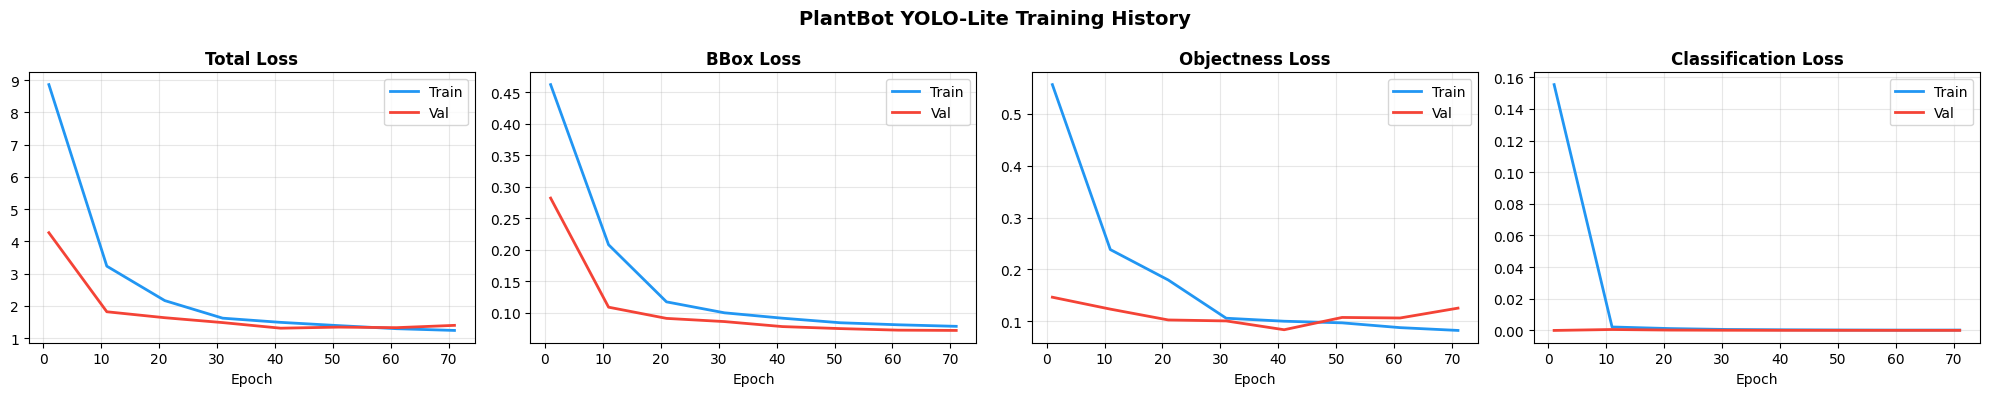

✅ Đã lưu biểu đồ: training_history.png


In [45]:
# ── Vẽ biểu đồ Training History ─────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
metrics = ["total", "bbox", "obj", "cls"]
titles  = ["Total Loss", "BBox Loss", "Objectness Loss", "Classification Loss"]

for ax, metric, title in zip(axes, metrics, titles):
    train_vals = [h[metric] for h in history["train"]]
    val_vals   = [h[metric] for h in history["val"]]
    epochs_x   = np.arange(1, len(train_vals) * 10 + 1, 10)

    ax.plot(epochs_x, train_vals, label="Train", color="#2196F3", linewidth=2)
    ax.plot(epochs_x, val_vals,   label="Val",   color="#F44336", linewidth=2)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("PlantBot YOLO-Lite Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()
print("✅ Đã lưu biểu đồ: training_history.png")

---
## Cell 5 — Inference & NMS → Vẽ Bounding Box

### Giải mã Grid Predictions
Với mỗi cell $(g_j, g_i)$ có `objectness > threshold`:

$$c_x = \frac{g_i + \sigma(t_x)}{S}, \quad c_y = \frac{g_j + \sigma(t_y)}{S}$$
$$w = \sigma(t_w), \quad h = \sigma(t_h)$$

Chuyển sang tọa độ góc:
$$x_1 = c_x - \frac{w}{2}, \quad y_1 = c_y - \frac{h}{2}$$
$$x_2 = c_x + \frac{w}{2}, \quad y_2 = c_y + \frac{h}{2}$$

### Non-Maximum Suppression (NMS)
Loại bỏ các box trùng lặp bằng cách:
1. Sắp xếp theo confidence giảm dần
2. Giữ box cao nhất, loại bỏ các box có $\text{IoU} > \theta_{nms}$
3. Lặp lại cho đến hết

In [38]:
# ═══════════════════════════════════════════════════════════════
# INFERENCE UTILITIES (Viết thủ công, không dùng thư viện)
# ═══════════════════════════════════════════════════════════════

def decode_grid_predictions(predictions, grid_size=7,
                            conf_threshold=0.25):
    """
    Giải mã output grid (S, S, 5+C) → list bounding boxes.

    Mỗi box: [x1, y1, x2, y2, confidence, class_id]
    Tọa độ normalize [0, 1] (nhân với img_size để ra pixel).
    """
    S = grid_size
    boxes = []

    # Apply sigmoid cho từng thành phần
    pred_xy  = torch.sigmoid(predictions[..., 0:2])
    pred_wh  = torch.sigmoid(predictions[..., 2:4])
    pred_obj = torch.sigmoid(predictions[..., 4])
    pred_cls = torch.sigmoid(predictions[..., 5:])

    for gj in range(S):
        for gi in range(S):
            obj_conf = pred_obj[gj, gi].item()
            if obj_conf < conf_threshold:
                continue

            # Giải mã tọa độ tâm
            tx = pred_xy[gj, gi, 0].item()
            ty = pred_xy[gj, gi, 1].item()
            cx = (gi + tx) / S
            cy = (gj + ty) / S

            # Giải mã kích thước
            w = pred_wh[gj, gi, 0].item()
            h = pred_wh[gj, gi, 1].item()

            # Tọa độ góc
            x1 = max(0.0, cx - w / 2)
            y1 = max(0.0, cy - h / 2)
            x2 = min(1.0, cx + w / 2)
            y2 = min(1.0, cy + h / 2)

            # Class với confidence
            if pred_cls.shape[-1] > 0:
                cls_scores = pred_cls[gj, gi]
                cls_conf, cls_id = cls_scores.max(dim=-1)
                score = obj_conf * cls_conf.item()
                cls_id = cls_id.item()
            else:
                score = obj_conf
                cls_id = 0

            boxes.append([x1, y1, x2, y2, score, cls_id])

    return boxes


def compute_iou(box_a, box_b):
    """
    Tính IoU giữa 2 boxes [x1, y1, x2, y2].

    IoU = Area(Intersection) / Area(Union)
        = Area(A ∩ B) / (Area(A) + Area(B) - Area(A ∩ B))
    """
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union  = area_a + area_b - inter

    return inter / (union + 1e-6)


def non_max_suppression(boxes, nms_threshold=0.45):
    """
    NMS thủ công (không dùng torchvision.ops.nms).

    Thuật toán:
      1. Sắp xếp boxes theo score giảm dần
      2. Chọn box score cao nhất → thêm vào selected
      3. Loại bỏ mọi box còn lại có IoU > threshold
      4. Lặp lại cho đến khi hết candidates

    Complexity: O(N²) nhưng N rất nhỏ (max S²=49) → không vấn đề.
    """
    if not boxes:
        return []

    # Sort by confidence descending
    boxes = sorted(boxes, key=lambda b: b[4], reverse=True)
    selected = []

    while boxes:
        best = boxes.pop(0)
        selected.append(best)

        # Loại bỏ boxes trùng lặp (IoU cao)
        boxes = [
            b for b in boxes
            if compute_iou(best[:4], b[:4]) < nms_threshold
        ]

    return selected


print("✅ Inference utilities đã sẵn sàng")

✅ Inference utilities đã sẵn sàng


✅ Loaded best model from epoch 5
   Val loss: 1.3051
   Classes: ['Diseased']

📷 34_jpg.rf.c8afc16c049d852269dfe5966b48ce75.jpg


Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.


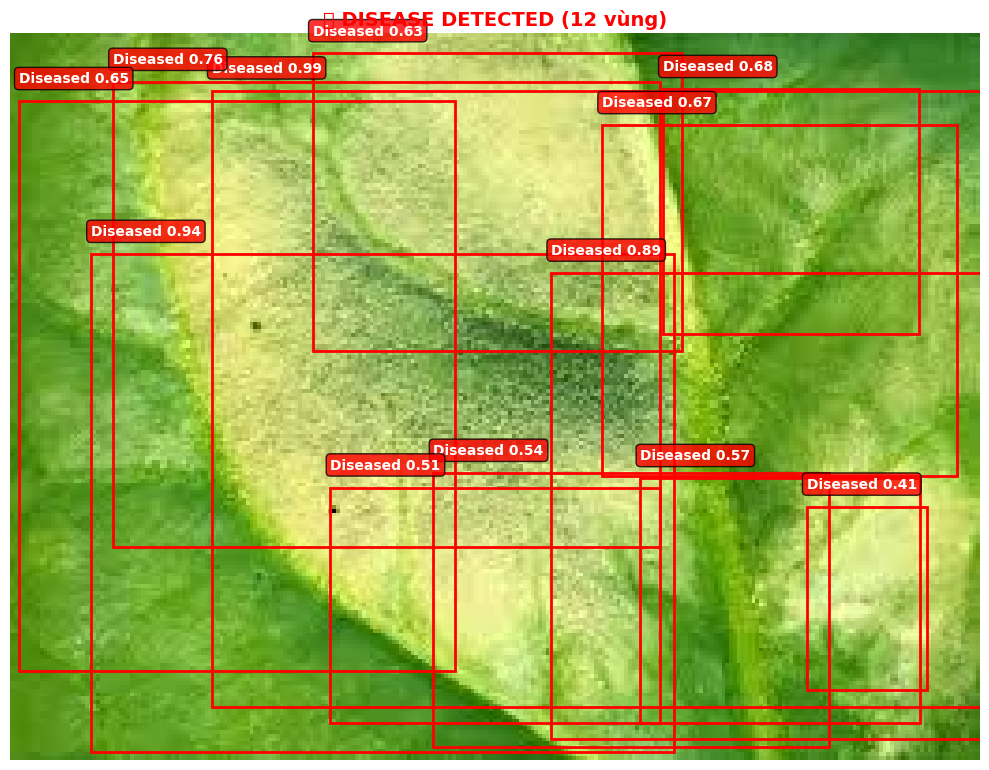

  → Diseased: conf=0.992 box=[0.206,0.076,1.000,0.924]
  → Diseased: conf=0.937 box=[0.081,0.301,0.683,0.987]
  → Diseased: conf=0.885 box=[0.556,0.327,1.000,0.969]
  → Diseased: conf=0.763 box=[0.104,0.064,0.668,0.704]
  → Diseased: conf=0.680 box=[0.671,0.074,0.935,0.411]
  → Diseased: conf=0.666 box=[0.608,0.124,0.974,0.607]
  → Diseased: conf=0.651 box=[0.007,0.091,0.457,0.876]
  → Diseased: conf=0.633 box=[0.310,0.025,0.691,0.434]
  → Diseased: conf=0.574 box=[0.648,0.610,0.936,0.946]
  → Diseased: conf=0.535 box=[0.435,0.602,0.842,0.980]
  → Diseased: conf=0.506 box=[0.328,0.623,0.669,0.946]
  → Diseased: conf=0.409 box=[0.819,0.649,0.943,0.901]

📷 2-Copy_jpg.rf.a9668d82964b6a956e8a5ee557785c6f.jpg


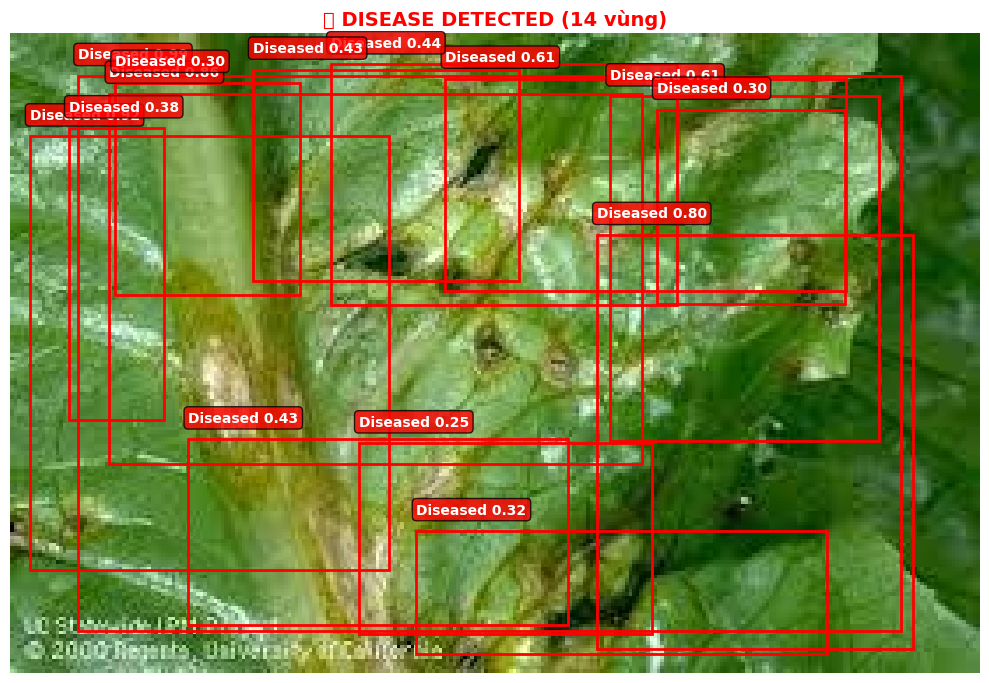

  → Diseased: conf=0.991 box=[0.068,0.064,0.916,0.932]
  → Diseased: conf=0.916 box=[0.018,0.158,0.389,0.837]
  → Diseased: conf=0.864 box=[0.101,0.092,0.650,0.670]
  → Diseased: conf=0.796 box=[0.603,0.312,0.929,0.960]
  → Diseased: conf=0.613 box=[0.617,0.096,0.894,0.635]
  → Diseased: conf=0.608 box=[0.447,0.068,0.860,0.401]
  → Diseased: conf=0.444 box=[0.329,0.046,0.686,0.422]
  → Diseased: conf=0.425 box=[0.182,0.632,0.574,0.923]
  → Diseased: conf=0.425 box=[0.248,0.054,0.523,0.385]
  → Diseased: conf=0.383 box=[0.059,0.146,0.157,0.601]
  → Diseased: conf=0.321 box=[0.417,0.776,0.840,0.968]
  → Diseased: conf=0.301 box=[0.665,0.117,0.859,0.421]
  → Diseased: conf=0.298 box=[0.106,0.075,0.297,0.407]
  → Diseased: conf=0.253 box=[0.358,0.638,0.660,0.936]

📷 14_jpg.rf.1242d6f87d01683d3f502f3a1254ba43.jpg


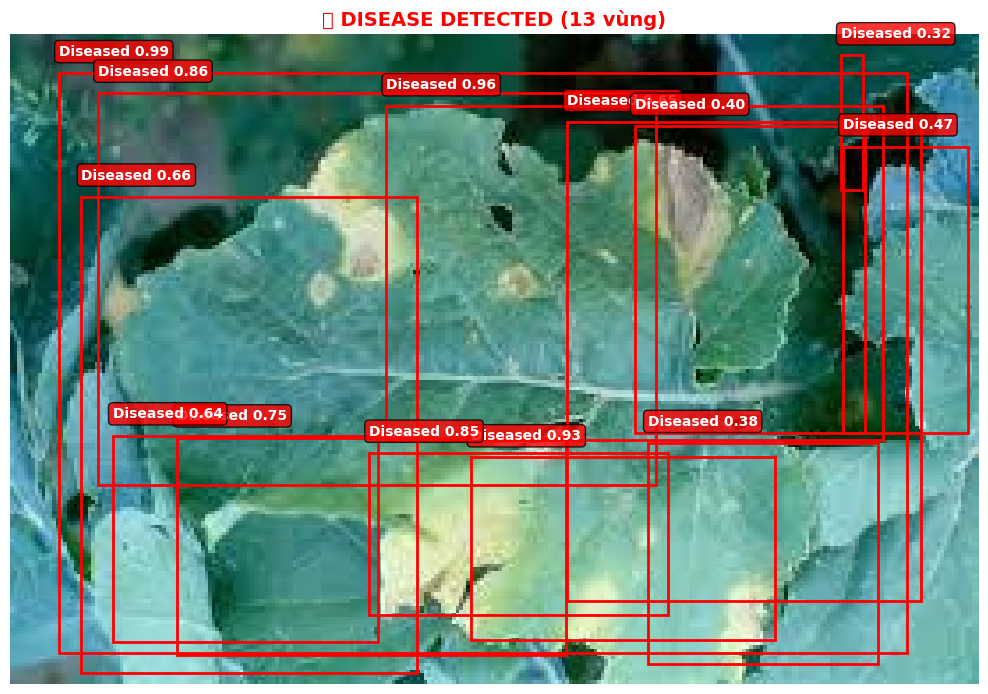

  → Diseased: conf=0.994 box=[0.049,0.058,0.925,0.949]
  → Diseased: conf=0.955 box=[0.387,0.109,0.899,0.623]
  → Diseased: conf=0.932 box=[0.475,0.649,0.788,0.929]
  → Diseased: conf=0.860 box=[0.089,0.088,0.666,0.690]
  → Diseased: conf=0.849 box=[0.369,0.642,0.677,0.891]
  → Diseased: conf=0.754 box=[0.171,0.618,0.572,0.953]
  → Diseased: conf=0.665 box=[0.072,0.248,0.419,0.980]
  → Diseased: conf=0.651 box=[0.574,0.133,0.939,0.870]
  → Diseased: conf=0.637 box=[0.104,0.615,0.378,0.932]
  → Diseased: conf=0.470 box=[0.858,0.171,0.988,0.612]
  → Diseased: conf=0.401 box=[0.643,0.139,0.881,0.611]
  → Diseased: conf=0.383 box=[0.657,0.627,0.895,0.966]
  → Diseased: conf=0.321 box=[0.856,0.031,0.879,0.237]

📷 spinach_downymildew3_jpg.rf.2908e80e2d93429f1d647d55f96c7820.jpg


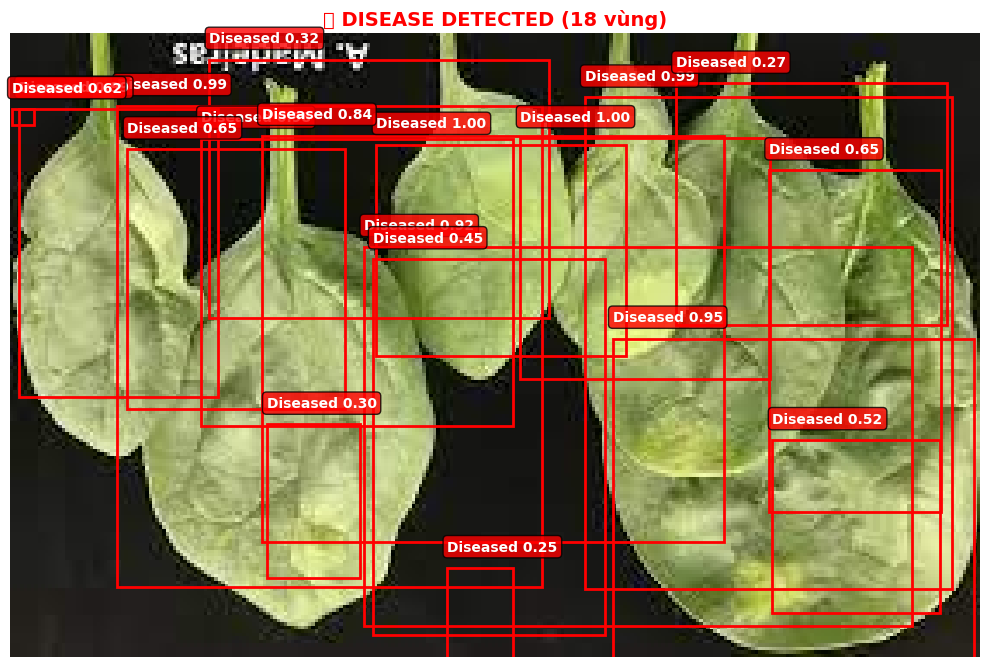

  → Diseased: conf=0.996 box=[0.376,0.176,0.633,0.514]
  → Diseased: conf=0.995 box=[0.524,0.165,0.781,0.551]
  → Diseased: conf=0.990 box=[0.109,0.113,0.546,0.886]
  → Diseased: conf=0.990 box=[0.591,0.100,0.970,0.888]
  → Diseased: conf=0.988 box=[0.007,0.118,0.212,0.581]
  → Diseased: conf=0.979 box=[0.195,0.166,0.517,0.627]
  → Diseased: conf=0.951 box=[0.620,0.486,0.992,1.000]
  → Diseased: conf=0.918 box=[0.363,0.339,0.928,0.947]
  → Diseased: conf=0.841 box=[0.258,0.161,0.734,0.812]
  → Diseased: conf=0.645 box=[0.781,0.216,0.959,0.765]
  → Diseased: conf=0.645 box=[0.119,0.183,0.343,0.599]
  → Diseased: conf=0.621 box=[0.000,0.118,0.023,0.143]
  → Diseased: conf=0.515 box=[0.784,0.649,0.957,0.926]
  → Diseased: conf=0.448 box=[0.372,0.359,0.612,0.962]
  → Diseased: conf=0.317 box=[0.204,0.039,0.554,0.454]
  → Diseased: conf=0.297 box=[0.263,0.624,0.359,0.870]
  → Diseased: conf=0.274 box=[0.685,0.077,0.964,0.465]
  → Diseased: conf=0.253 box=[0.449,0.855,0.517,1.000]

📷 lettuce

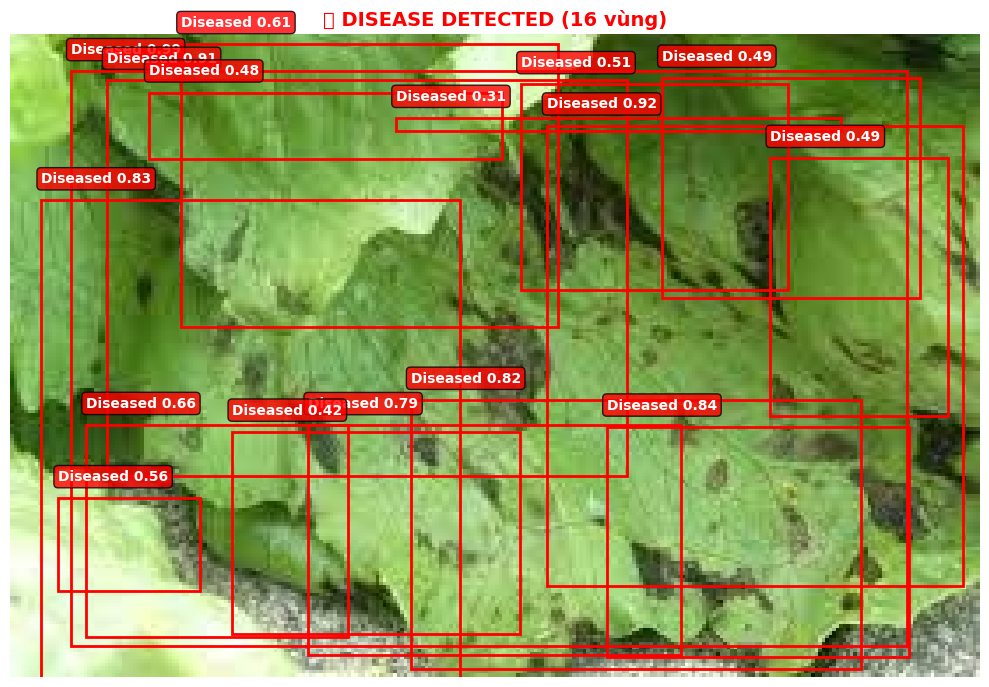

  → Diseased: conf=0.991 box=[0.061,0.055,0.923,0.949]
  → Diseased: conf=0.919 box=[0.551,0.140,0.981,0.856]
  → Diseased: conf=0.913 box=[0.098,0.069,0.634,0.685]
  → Diseased: conf=0.841 box=[0.613,0.608,0.925,0.967]
  → Diseased: conf=0.828 box=[0.030,0.256,0.462,1.000]
  → Diseased: conf=0.818 box=[0.411,0.566,0.875,0.984]
  → Diseased: conf=0.795 box=[0.306,0.606,0.690,0.964]
  → Diseased: conf=0.660 box=[0.077,0.605,0.347,0.935]
  → Diseased: conf=0.607 box=[0.174,0.013,0.563,0.452]
  → Diseased: conf=0.559 box=[0.048,0.719,0.194,0.864]
  → Diseased: conf=0.507 box=[0.525,0.076,0.801,0.396]
  → Diseased: conf=0.493 box=[0.782,0.190,0.966,0.591]
  → Diseased: conf=0.489 box=[0.670,0.066,0.936,0.409]
  → Diseased: conf=0.484 box=[0.141,0.089,0.506,0.192]
  → Diseased: conf=0.421 box=[0.227,0.616,0.524,0.931]
  → Diseased: conf=0.310 box=[0.396,0.128,0.855,0.148]

📷 13_jpg.rf.1a17f843bb7dbcc677fecb739b921b0b.jpg


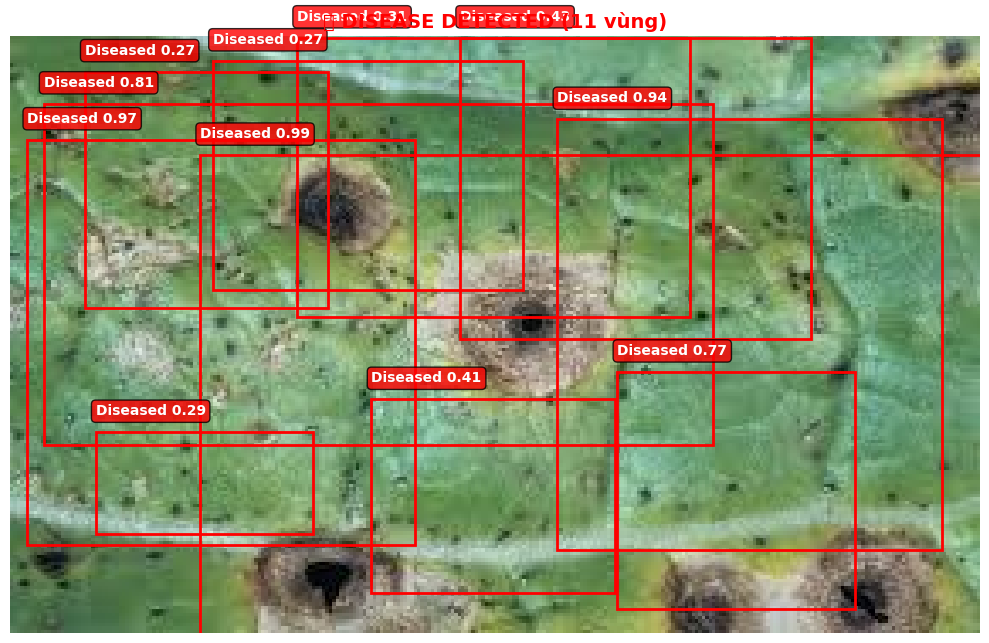

  → Diseased: conf=0.994 box=[0.194,0.196,1.000,1.000]
  → Diseased: conf=0.970 box=[0.016,0.171,0.416,0.850]
  → Diseased: conf=0.939 box=[0.562,0.136,0.959,0.858]
  → Diseased: conf=0.811 box=[0.033,0.111,0.723,0.682]
  → Diseased: conf=0.772 box=[0.624,0.560,0.869,0.957]
  → Diseased: conf=0.425 box=[0.462,0.000,0.824,0.505]
  → Diseased: conf=0.413 box=[0.371,0.606,0.622,0.930]
  → Diseased: conf=0.309 box=[0.294,0.000,0.699,0.467]
  → Diseased: conf=0.290 box=[0.087,0.661,0.311,0.832]
  → Diseased: conf=0.273 box=[0.075,0.057,0.326,0.452]
  → Diseased: conf=0.267 box=[0.207,0.039,0.528,0.422]


In [39]:
# ═══════════════════════════════════════════════════════════════
# LOAD BEST MODEL & INFERENCE VISUALIZATION
# ═══════════════════════════════════════════════════════════════

# Load best checkpoint
ckpt = torch.load("plantbot_best.pt", map_location=CFG.DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"✅ Loaded best model from epoch {ckpt['epoch']}")
print(f"   Val loss: {ckpt['best_val_loss']:.4f}")
print(f"   Classes: {ckpt['class_names']}")

# Color palette cho visualization
COLORS = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255),
    (255, 255, 0), (255, 0, 255), (0, 255, 255),
]


def predict_and_visualize(model, image_path, device,
                          conf_threshold=0.25, nms_threshold=0.45,
                          class_names=None, img_size=224, grid_size=7):
    """
    Pipeline hoàn chỉnh: Load ảnh → Inference → NMS → Vẽ BBox.

    Logic cho hệ thống IoT:
      - Có box nào được detect → Disease (cây bị bệnh)
      - Không có box nào       → No Disease (cây khỏe mạnh)
    """
    model.eval()

    # Load & preprocess
    img_orig = cv2.imread(str(image_path))
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = img_orig.shape[:2]

    img_resized = cv2.resize(img_orig, (img_size, img_size))
    img_f = img_resized.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_f = (img_f - mean) / std
    img_tensor = torch.from_numpy(img_f).permute(2, 0, 1).unsqueeze(0)
    img_tensor = img_tensor.to(device)

    # Inference
    with torch.no_grad():
        pred = model(img_tensor)[0].cpu()  # (S, S, 5+C)

    # Decode + NMS
    boxes = decode_grid_predictions(
        pred, grid_size=grid_size, conf_threshold=conf_threshold
    )
    boxes = non_max_suppression(boxes, nms_threshold=nms_threshold)

    # Vẽ lên ảnh gốc
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_orig)

    if len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2, score, cls_id = box
            # Scale về pixel gốc
            px1 = x1 * w_orig
            py1 = y1 * h_orig
            px2 = x2 * w_orig
            py2 = y2 * h_orig

            color_idx = int(cls_id) % len(COLORS)
            c = tuple(v / 255.0 for v in COLORS[color_idx])

            cls_name = class_names[int(cls_id)] if class_names else f"cls_{int(cls_id)}"
            label = f"{cls_name} {score:.2f}"

            rect = patches.Rectangle(
                (px1, py1), px2 - px1, py2 - py1,
                linewidth=2, edgecolor=c, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                px1, py1 - 5, label,
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=c, alpha=0.8)
            )

        status = f"🦠 DISEASE DETECTED ({len(boxes)} vùng)"
        status_color = "red"
    else:
        status = "✅ NO DISEASE — Cây khỏe mạnh"
        status_color = "green"

    ax.set_title(status, fontsize=14, fontweight='bold', color=status_color)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return boxes


# ── Chạy inference trên vài ảnh test ──────────────────────────
import glob

test_images = sorted(glob.glob(os.path.join(CFG.DATA_DIR, "test", "images", "*.jpg")))

if test_images:
    n_show = min(6, len(test_images))
    # Chọn ngẫu nhiên để đa dạng
    sample_indices = random.sample(range(len(test_images)), n_show)

    for idx in sample_indices:
        img_path = test_images[idx]
        print(f"\n📷 {Path(img_path).name}")
        detected = predict_and_visualize(
            model, img_path, CFG.DEVICE,
            conf_threshold=CFG.CONF_THRESHOLD,
            nms_threshold=CFG.NMS_THRESHOLD,
            class_names=CLASS_NAMES,
            img_size=CFG.IMG_SIZE,
            grid_size=CFG.GRID_SIZE,
        )
        if detected:
            for b in detected:
                name = CLASS_NAMES[int(b[5])] if CLASS_NAMES else f"cls_{int(b[5])}"
                print(f"  → {name}: conf={b[4]:.3f} box=[{b[0]:.3f},{b[1]:.3f},{b[2]:.3f},{b[3]:.3f}]")
else:
    print("⚠️ Không tìm thấy ảnh test.")

In [40]:
import os

model_file = "plantbot_best.pt"

if os.path.exists(model_file):
    size_bytes = os.path.getsize(model_file)
    size_mb = size_bytes / (1024 * 1024)

    total_p = sum(p.numel() for p in model.parameters())

    print("\n" + "=" * 55)
    print("📦 THÔNG TIN MÔ HÌNH plantbot_best.pt")
    print("=" * 55)
    print(f"  File size     : {size_mb:.2f} MB")
    print(f"  Parameters    : {total_p:,}")
    print(f"  Input size    : {CFG.IMG_SIZE}×{CFG.IMG_SIZE}")
    print(f"  Grid          : {CFG.GRID_SIZE}×{CFG.GRID_SIZE}")
    print(f"  Classes       : {CLASS_NAMES}")
    print(f"  Best val loss : {best_val_loss:.4f}")
    print("=" * 55)
    print("\n💡 Để dùng trên Raspberry Pi 5:")
    print("   1. Copy file plantbot_best.pt sang RPi5")
    print("   2. Load với torch.load('plantbot_best.pt', map_location='cpu')")
    print("   3. Tạo model = YOLOLiteDetector(num_classes, grid_size)")
    print("   4. model.load_state_dict(ckpt['model_state'])")
    print("   5. model.eval() → Inference!")
else:
    print("❌ Chưa tìm thấy plantbot_best.pt")


📦 THÔNG TIN MÔ HÌNH plantbot_best.pt
  File size     : 6.35 MB
  Parameters    : 545,926
  Input size    : 224×224
  Grid          : 7×7
  Classes       : ['Diseased']
  Best val loss : 1.3051

💡 Để dùng trên Raspberry Pi 5:
   1. Copy file plantbot_best.pt sang RPi5
   2. Load với torch.load('plantbot_best.pt', map_location='cpu')
   3. Tạo model = YOLOLiteDetector(num_classes, grid_size)
   4. model.load_state_dict(ckpt['model_state'])
   5. model.eval() → Inference!
